## exp04_augs.ipynb - Влияние аугментаций на обучение CNN
**Цель:** Экспериментально оценить, как различные стратегии аугментации влияют на качество  
**Данные:** `data/train/`, `data/test/`   
**Подход:** Фиксируем архитектуру, гиперпараметры и ранний стоп. Меняем только состав трансформаций для train-данных. Сравниваем по F1-macro и кривым обучения

Начало эксперимента CNN_base. Число эпох = 2
Эпоха 1. Валидационные метрики: acc = 0.25130616509926856, f1 = 0.0573814494482553
Эпоха 2. Валидационные метрики: acc = 0.13549285963079066, f1 = 0.06145335336095275
CNN_base | Acc=0.143 | F1=0.064 | Logged to MLflow & metrics.csv
Начало эксперимента CNN_geo. Число эпох = 2
Эпоха 1. Валидационные метрики: acc = 0.25130616509926856, f1 = 0.0573814494482553
Эпоха 2. Валидационные метрики: acc = 0.17572274468826193, f1 = 0.08151705869367157
CNN_geo | Acc=0.194 | F1=0.090 | Logged to MLflow & metrics.csv
Начало эксперимента CNN_photo. Число эпох = 2
Эпоха 1. Валидационные метрики: acc = 0.25130616509926856, f1 = 0.0573814494482553
Эпоха 2. Валидационные метрики: acc = 0.17641936607453848, f1 = 0.08176095593708989
CNN_photo | Acc=0.185 | F1=0.086 | Logged to MLflow & metrics.csv
Начало эксперимента CNN_combined. Число эпох = 2
Эпоха 1. Валидационные метрики: acc = 0.11093695576454198, f1 = 0.029204253059443665
Эпоха 2. Валидационные метрики: acc

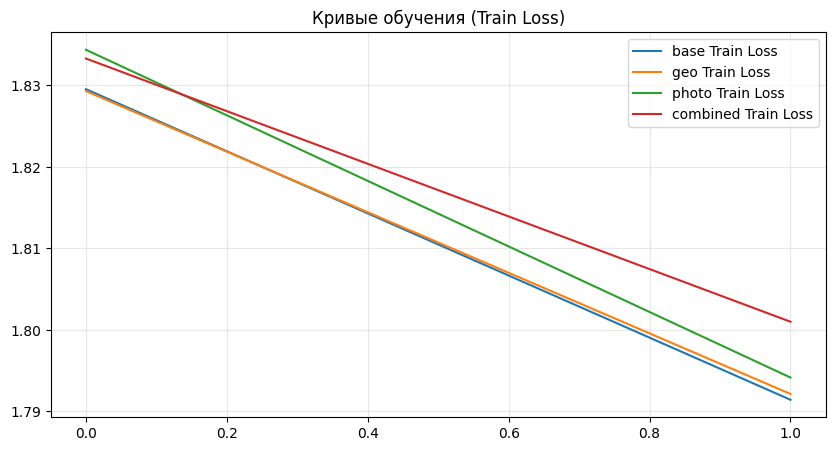

In [ ]:
import matplotlib.pyplot as plt
from src.data.loader import create_dataloaders
from src.models.cnn import train_cnn, eval_cnn
from src.constants import DATA_PATH, FIGURES_PATH
from src.utils.experiment_logger import log_experiment
from src.features.image_transforms import get_train_transform


augs = {
    "base": get_train_transform("base"),
    "geo": get_train_transform("geo"),
    "photo": get_train_transform("photo"),
    "combined": get_train_transform("combined"),
}

batch_size = 64
experiment_name = "cnn_variants"
plt.figure(figsize=(10,5))
for aug_name, tf in augs.items():
    lr = 1e-3
    wd = 1e-4
    patience = 5
    epochs=2

    train_loader, val_loader, test_loader = create_dataloaders(DATA_PATH, batch_size=batch_size, train_transform=tf)

    model_name = f"CNN_aug_{aug_name}"
    model, hist = train_cnn(train_loader, val_loader, epochs=epochs, lr=lr, name=model_name, 
                                weight_decay=wd, patience=patience)
    
    plt.plot(hist["train_loss"], label=f"{aug_name} Train Loss")
    
    y_true, y_pred = eval_cnn(model, test_loader)
            
    training_cfg = {
        "experiment_name": experiment_name,
        "model_name": model_name,
        "epochs": len(hist["train_loss"]),
        "lr": lr,
        "wd": wd,
        "patience": patience,
        "batch_size": batch_size,
        "augmentation": aug_name
    }

    log_experiment(experiment_name, model_name, y_true, y_pred, training_cfg)
    

plt.title("Кривые обучения (Train Loss)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{FIGURES_PATH}/augs_curves.png")
plt.show()